In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Optional
import warnings
warnings.filterwarnings('ignore')

In [15]:
df = pd.read_csv(r"C:\Users\DELL\superstore_final_dataset (1).csv", encoding='latin1')

In [16]:
df.columns = df.columns.str.strip().str.replace('\ufeff', '').str.replace(' ', '_').str.lower()
print(df.columns)

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales'],
      dtype='object')


In [20]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 3955 entries, 0 to 9799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         3955 non-null   int64         
 1   order_id       3955 non-null   object        
 2   order_date     3955 non-null   datetime64[ns]
 3   ship_date      3955 non-null   object        
 4   ship_mode      3955 non-null   object        
 5   customer_id    3955 non-null   object        
 6   customer_name  3955 non-null   object        
 7   segment        3955 non-null   object        
 8   country        3955 non-null   object        
 9   city           3955 non-null   object        
 10  state          3955 non-null   object        
 11  postal_code    3955 non-null   float64       
 12  region         3955 non-null   object        
 13  product_id     3955 non-null   object        
 14  category       3955 non-null   object        
 15  sub_category   3955 non-nu

,row_id,order_date,postal_code,sales,year,month
count,3955.000000,3955,3955.000000,3955.000000,3955.000000,3955.000000
mean,4868.681416,2017-03-14 18:03:54.841972224,55074.172946,218.898418,2016.728445,6.452845
min,1.000000,2015-01-02 00:00:00,1040.000000,0.556000,2015.000000,1.000000
25%,2465.500000,2016-04-05 00:00:00,22204.000000,17.472000,2016.000000,3.000000
50%,4884.000000,2017-05-02 00:00:00,55407.000000,55.008000,2017.000000,6.000000
75%,7319.000000,2018-03-07 00:00:00,90006.000000,199.925000,2018.000000,9.000000
max,9800.000000,2018-12-11 00:00:00,99301.000000,17499.950000,2018.000000,12.000000
std,2821.087831,NaN,32226.772397,560.799822,1.119373,3.499547


In [18]:
# Convert date column
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

# Drop missing values
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

In [19]:
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.strftime('%b')

In [22]:
total_revenue = df['sales'].sum()
avg_order_value = df['sales'].mean()

print("Total Revenue:", total_revenue)
print("Average Order Value:", avg_order_value)

Total Revenue: 865743.2436
Average Order Value: 218.89841810366624


In [23]:
df['profit'] = df['sales'] * 0.1

In [24]:
total_profit = df['profit'].sum()
profit_margin = (total_profit / df['sales'].sum()) * 100

print("Total Profit:", total_profit)
print("Profit Margin:", profit_margin)

Total Profit: 86574.32436
Profit Margin: 10.0


In [25]:
print(df.columns)

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'year', 'month', 'month_name', 'profit'],
      dtype='object')


In [27]:
# KPIs
total_revenue = df['sales'].sum()
avg_order_value = df['sales'].mean()

# Optional profit
df['profit'] = df['sales'] * 0.1

total_profit = df['profit'].sum()

print("Revenue:", total_revenue)
print("Avg Order Value:", avg_order_value)
print("Estimated Profit:", total_profit)

Revenue: 865743.2436
Avg Order Value: 218.89841810366624
Estimated Profit: 86574.32436


In [28]:
total_revenue = df['sales'].sum()
total_profit = df['profit'].sum()
profit_margin = (total_profit / total_revenue) * 100
avg_order_value = df['sales'].mean()

print("Total Revenue:", total_revenue)
print("Total Profit:", total_profit)
print("Profit Margin:", profit_margin)
print("Average Order Value:", avg_order_value)

Total Revenue: 865743.2436
Total Profit: 86574.32436
Profit Margin: 10.0
Average Order Value: 218.89841810366624


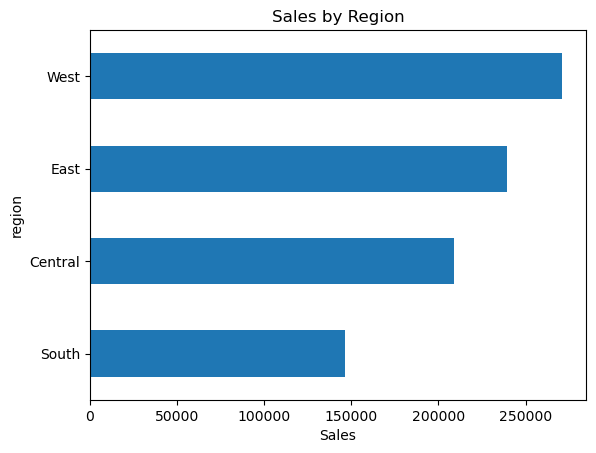

In [29]:
region_sales = df.groupby('region')['sales'].sum().sort_values()

region_sales.plot(kind='barh')
plt.title("Sales by Region")
plt.xlabel("Sales")
plt.show()

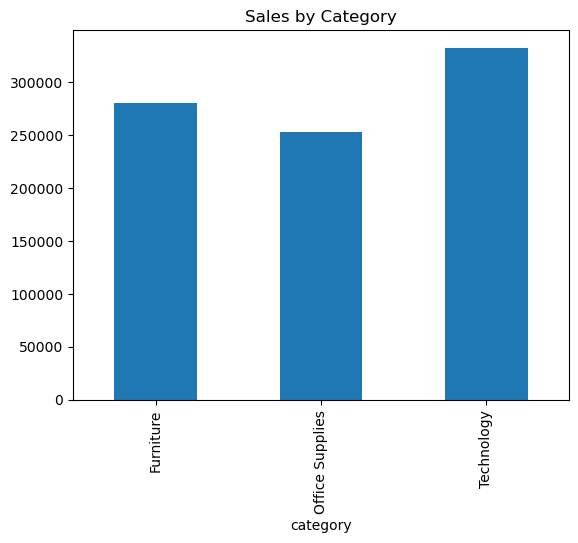

In [30]:
category_sales = df.groupby('category')['sales'].sum()

category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.show()

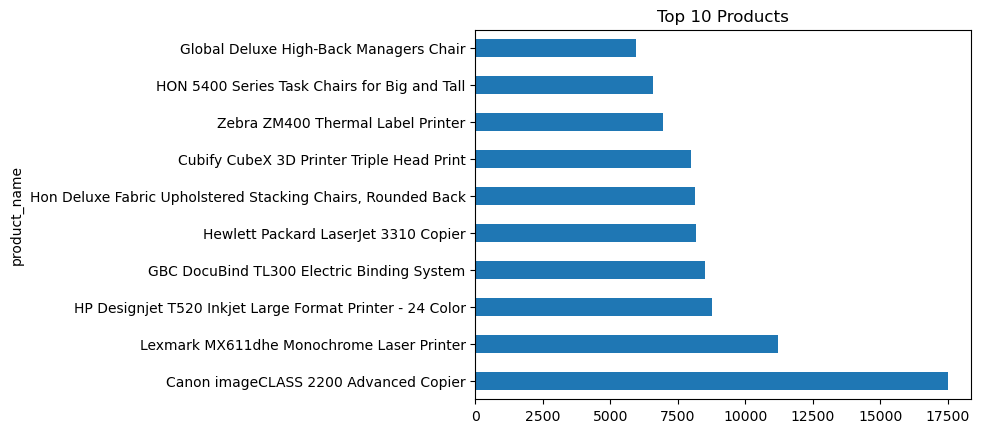

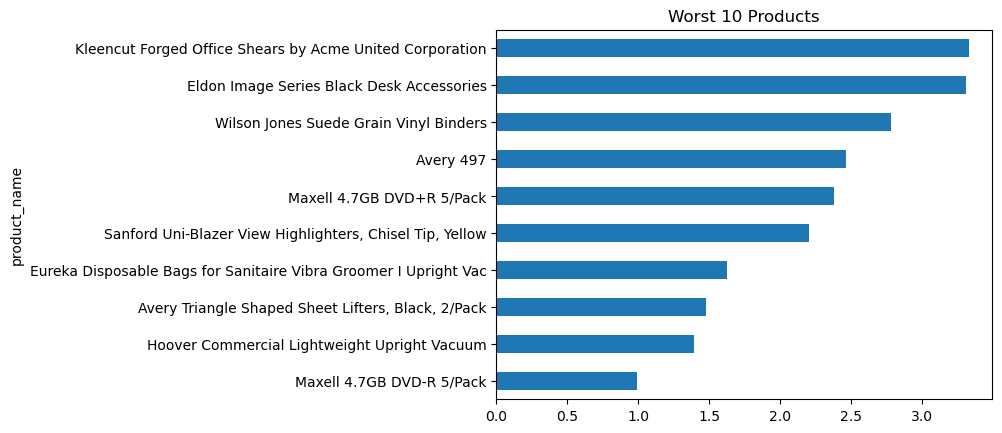

In [31]:
product_sales = df.groupby('product_name')['sales'].sum()

top_products = product_sales.sort_values(ascending=False).head(10)
worst_products = product_sales.sort_values().head(10)

# Top
top_products.plot(kind='barh')
plt.title("Top 10 Products")
plt.show()

# Worst
worst_products.plot(kind='barh')
plt.title("Worst 10 Products")
plt.show()

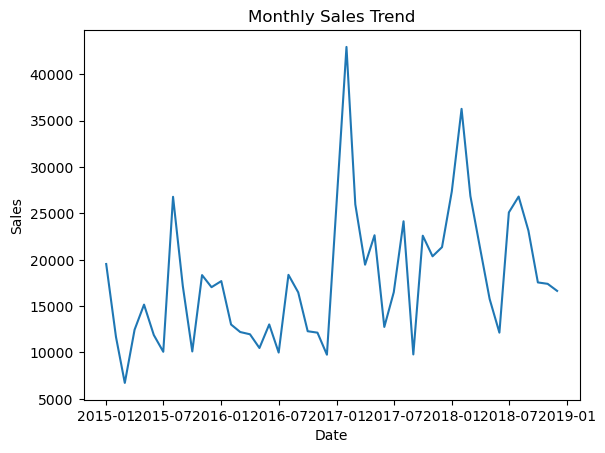

In [32]:
monthly_sales = df.groupby(['year','month'])['sales'].sum().reset_index()

monthly_sales['date'] = pd.to_datetime(monthly_sales[['year','month']].assign(day=1))

plt.plot(monthly_sales['date'], monthly_sales['sales'])
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

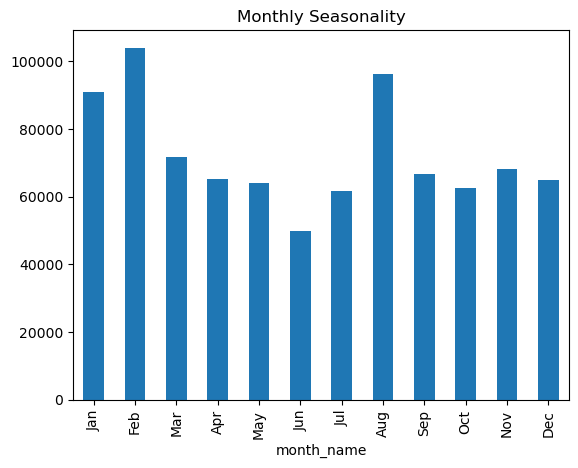

In [33]:
monthwise = df.groupby('month_name')['sales'].sum()

monthwise = monthwise.reindex([
    'Jan','Feb','Mar','Apr','May','Jun',
    'Jul','Aug','Sep','Oct','Nov','Dec'
])

monthwise.plot(kind='bar')
plt.title("Monthly Seasonality")
plt.show()

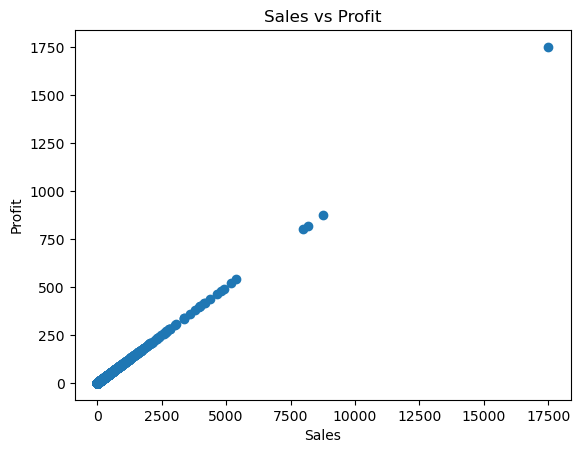

In [34]:
plt.scatter(df['sales'], df['profit'])
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

In [ ]:
Business Insights 
Top Products generate majority revenue → Focus on them  
Some products have high sales but low profit → Pricing issue  
Certain months show low sales → Seasonality effect  
Some regions underperform → Need targeted marketing  

In [ ]:
Tactical Improvements
improvements = [
    "Focus marketing on high-performing regions",
    "Improve pricing strategy for low-profit products",
    "Offer discounts during low-sales months",
    "Bundle products to increase average order value",
    "Promote best-selling products more"
]

for i, imp in enumerate(improvements, 1):
    print(f"{i}. {imp}")

In [35]:
df.to_csv("cleaned_sales_data.csv", index=False)